RestNe150

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input

In [7]:
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

In [9]:
BASE_DIR = "/kaggle/input/datasets/nirashajayamanna/original-images/Original-Images"

if not os.path.exists(BASE_DIR):
    raise FileNotFoundError(f"BASE_DIR not found: {BASE_DIR}")

In [10]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
EPOCHS = 14
VAL_SPLIT = 0.2
SEED = 42

In [11]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VAL_SPLIT,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [12]:
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=VAL_SPLIT
)

train_data = train_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_data = val_datagen.flow_from_directory(
    BASE_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

NUM_CLASSES = train_data.num_classes
print("Class indices:", train_data.class_indices)

Found 480 images belonging to 6 classes.
Found 120 images belonging to 6 classes.
Class indices: {'Eggplant Cercospora Leaf Disease': 0, 'Eggplant Healthy Leaf Disease': 1, 'Eggplant Insect Pest Disease': 2, 'Eggplant Leaf Spot Disease': 3, 'Eggplant Powdery mildew Disease': 4, 'Eggplant Wilt Disease': 5}


In [13]:
# -------------------------
# 4) Build ResNet50 model (transfer learning)
# -------------------------
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False  # freeze backbone for first stage

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

I0000 00:00:1772257175.512411      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772257175.518596      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,113,798 (91.99 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [14]:
BEST_MODEL = "eggplant_resnet50_Aug_best.keras"

callbacks = [
    ModelCheckpoint(BEST_MODEL, monitor="val_accuracy", save_best_only=True),
    EarlyStopping(monitor="val_accuracy", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1)
]

# -------------------------
# 6) Train (stage 1: feature extraction)
# -------------------------
history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("✅ Best model saved to:", BEST_MODEL)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/14


I0000 00:00:1772257233.639165     160 service.cc:152] XLA service 0x7c27680021d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772257233.639210     160 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1772257233.639214     160 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1772257235.695135     160 cuda_dnn.cc:529] Loaded cuDNN version 91002


 2/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.1875 - loss: 3.4318 

I0000 00:00:1772257241.240450     160 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


30/30 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.4215 - loss: 1.9444 - val_accuracy: 0.6750 - val_loss: 0.8714 - learning_rate: 0.0010
Epoch 2/14
30/30 ━━━━━━━━━━━━━━━━━━━━ 20s 646ms/step - accuracy: 0.7338 - loss: 0.7425 - val_accuracy: 0.8333 - val_loss: 0.4557 - learning_rate: 0.0010
Epoch 3/14
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 616ms/step - accuracy: 0.7921 - loss: 0.4782 - val_accuracy: 0.8250 - val_loss: 0.4169 - learning_rate: 0.0010
Epoch 4/14
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 623ms/step - accuracy: 0.8675 - loss: 0.3837 - val_accuracy: 0.8250 - val_loss: 0.4926 - learning_rate: 0.0010
Epoch 5/14
30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 644ms/step - accuracy: 0.8493 - loss: 0.3460 - val_accuracy: 0.8750 - val_loss: 0.3116 - learning_rate: 0.0010
Epoch 6/14
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 616ms/step - accuracy: 0.8866 - loss: 0.2969 - val_accuracy: 0.8500 - val_loss: 0.4428 - learning_rate: 0.0010
Epoch 7/14
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.9062 - loss: 0.2411
Epoch 7: R

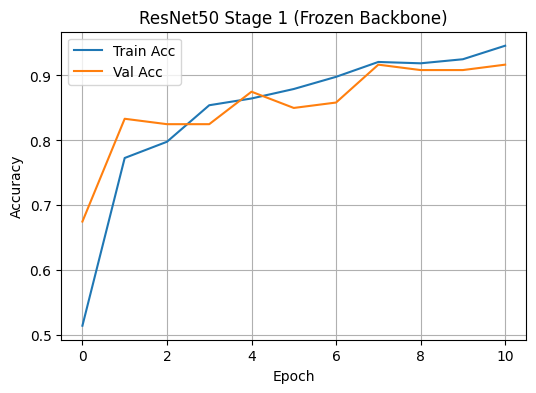

In [16]:
# 8) Plot accuracy
# -------------------------
def plot_history(h, title):
    plt.figure(figsize=(6,4))
    plt.plot(h.history["accuracy"], label="Train Acc")
    plt.plot(h.history["val_accuracy"], label="Val Acc")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_history(history1, "ResNet50 Stage 1 (Frozen Backbone)")


In [17]:
# Evaluate on validation set
val_loss, val_acc = model.evaluate(val_data)

print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 187ms/step - accuracy: 0.9319 - loss: 0.2382
Validation Accuracy: 0.9166666865348816
Validation Loss: 0.25861936807632446


In [18]:
from tensorflow.keras.models import load_model

best_model = load_model(BEST_MODEL)

val_loss, val_acc = best_model.evaluate(val_data)

print("Best Saved Model Accuracy:", val_acc)


8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 401ms/step - accuracy: 0.9319 - loss: 0.2382
Best Saved Model Accuracy: 0.9166666865348816


In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from tensorflow.keras.models import load_model

best_model = load_model(BEST_MODEL)
# Reset generator
val_data.reset()

# Get predictions
pred_probs = best_model.predict(val_data)
pred_classes = np.argmax(pred_probs, axis=1)

# True labels
true_classes = val_data.classes

# Class labels
class_labels = list(val_data.class_indices.keys())

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 647ms/step


In [20]:
report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
)

print("Classification Report:\n")
print(report)


Classification Report:

                                  precision    recall  f1-score   support

Eggplant Cercospora Leaf Disease       1.00      0.95      0.97        20
   Eggplant Healthy Leaf Disease       0.79      0.95      0.86        20
    Eggplant Insect Pest Disease       0.95      0.90      0.92        20
      Eggplant Leaf Spot Disease       0.88      0.75      0.81        20
 Eggplant Powdery mildew Disease       0.91      1.00      0.95        20
           Eggplant Wilt Disease       1.00      0.95      0.97        20

                        accuracy                           0.92       120
                       macro avg       0.92      0.92      0.92       120
                    weighted avg       0.92      0.92      0.92       120



In [22]:
# =========================
# Load Saved .keras Model + Predict on Your Own Image (Kaggle Ready)
# =========================

import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image



In [23]:
MODEL_PATH = "eggplant_resnet50_Aug_best.keras"

In [24]:
model = tf.keras.models.load_model(MODEL_PATH)
print("✅ Model loaded:", MODEL_PATH)
print("✅ Model output shape:", model.output_shape)

✅ Model loaded: eggplant_resnet50_Aug_best.keras
✅ Model output shape: (None, 6)


In [30]:
TRAIN_BASE_DIR = "/kaggle/input/datasets/nirashajayamanna/original-images/Original-Images"

In [31]:
if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}\nCheck /kaggle/input/... path")

if not os.path.exists(TEST_IMAGE_PATH):
    raise FileNotFoundError(f"Test image not found: {TEST_IMAGE_PATH}\nUpload image or correct the path")

if not os.path.exists(TRAIN_BASE_DIR):
    raise FileNotFoundError(f"Train base dir not found: {TRAIN_BASE_DIR}\nCheck dataset path")

In [34]:
class_names = sorted([
    d for d in os.listdir(TRAIN_BASE_DIR)
    if os.path.isdir(os.path.join(TRAIN_BASE_DIR, d))
])

num_model_classes = int(model.output_shape[-1])
num_folder_classes = len(class_names)

print("✅ Classes found in folder:", num_folder_classes)
print("✅ Class names:", class_names)

if num_model_classes != num_folder_classes:
    raise ValueError(
        f"""❌ Class count mismatch!
        Model classes: {num_model_classes}
        Folder classes: {num_folder_classes}
        Fix: Use the same TRAIN_BASE_DIR you used during training, or load class_indices you saved."""
    )

✅ Classes found in folder: 6
✅ Class names: ['Eggplant Cercospora Leaf Disease', 'Eggplant Healthy Leaf Disease', 'Eggplant Insect Pest Disease', 'Eggplant Leaf Spot Disease', 'Eggplant Powdery mildew Disease', 'Eggplant Wilt Disease']


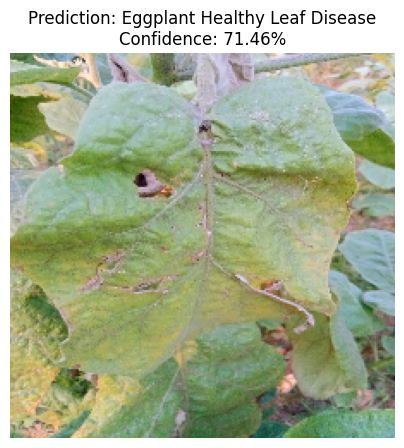


🔍 Full class probabilities:
Eggplant Healthy Leaf Disease  : 71.46%
Eggplant Insect Pest Disease   : 16.55%
Eggplant Leaf Spot Disease     : 5.24%
Eggplant Wilt Disease          : 4.80%
Eggplant Cercospora Leaf Disease : 1.91%
Eggplant Powdery mildew Disease : 0.04%


In [36]:
TEST_IMAGE_PATH = "/kaggle/input/datasets/nirashajayamanna/test-data1/test-data/Cercospora Leaf Spot/test2.jpg"
img = image.load_img(TEST_IMAGE_PATH, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)
pred = model.predict(img_array, verbose=0)[0]  # shape: (num_classes,)
pred_idx = int(np.argmax(pred))
confidence = float(pred[pred_idx])
pred_class = class_names[pred_idx]
plt.figure(figsize=(5,5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Prediction: {pred_class}\nConfidence: {confidence*100:.2f}%")
plt.show()

print("\n🔍 Full class probabilities:")
for name, p in sorted(zip(class_names, pred), key=lambda x: x[1], reverse=True):
    print(f"{name:30s} : {p*100:.2f}%")

YOLOV8n model

In [37]:
import os, shutil, random
from pathlib import Path

In [39]:
!pip -q install -U ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 17.5 MB/s eta 0:00:00a 0:00:01


In [40]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:

SRC_DIR = "/kaggle/input/datasets/nirashajayamanna/original-images/Original-Images"

assert os.path.exists(SRC_DIR), f"SRC_DIR not found: {SRC_DIR}"


OUT_ROOT = "/kaggle/working/eggplant_yolo_cls_Aug"
train_dir = Path(OUT_ROOT) / "train"
val_dir   = Path(OUT_ROOT) / "val"
test_dir  = Path(OUT_ROOT) / "test"

# clean old split (optional)
if os.path.exists(OUT_ROOT):
    shutil.rmtree(OUT_ROOT)

train_dir.mkdir(parents=True, exist_ok=True)
val_dir.mkdir(parents=True, exist_ok=True)
test_dir.mkdir(parents=True, exist_ok=True)

# Split ratios
TRAIN_RATIO = 0.7
VAL_RATIO   = 0.3  # (test will be created as well; you can keep small test)
TEST_RATIO  = 0.0  # set to 0.1 if you want test too; otherwise keep 0

SEED = 42
random.seed(SEED)

# helper: copy images into split folders
def copy_images(img_paths, dest_class_dir):
    dest_class_dir.mkdir(parents=True, exist_ok=True)
    for p in img_paths:
        shutil.copy2(p, dest_class_dir / Path(p).name)

# collect classes
classes = sorted([d for d in os.listdir(SRC_DIR) if os.path.isdir(os.path.join(SRC_DIR, d))])
print("✅ Classes:", classes)

# split per class
for cls in classes:
    cls_path = Path(SRC_DIR) / cls
    imgs = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.JPG", "*.JPEG", "*.PNG"):
        imgs.extend(list(cls_path.glob(ext)))
    imgs = sorted(imgs)
    random.shuffle(imgs)

    n = len(imgs)
    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)
    # n_test  = n - n_train - n_val (if using test)

    train_imgs = imgs[:n_train]
    val_imgs   = imgs[n_train:n_train+n_val]
    test_imgs  = imgs[n_train+n_val:] if TEST_RATIO > 0 else []

    copy_images(train_imgs, train_dir / cls)
    copy_images(val_imgs,   val_dir / cls)
    if TEST_RATIO > 0:
        copy_images(test_imgs, test_dir / cls)

print("✅ Split done!")
print("Train folder:", train_dir)
print("Val folder:", val_dir)


✅ Classes: ['Eggplant Cercospora Leaf Disease', 'Eggplant Healthy Leaf Disease', 'Eggplant Insect Pest Disease', 'Eggplant Leaf Spot Disease', 'Eggplant Powdery mildew Disease', 'Eggplant Wilt Disease']
✅ Split done!
Train folder: /kaggle/working/eggplant_yolo_cls_Aug/train
Val folder: /kaggle/working/eggplant_yolo_cls_Aug/val


In [61]:
WEIGHTS = "yolov8n-cls.pt"

model = YOLO(WEIGHTS)

results = model.train(
    data=OUT_ROOT,       # folder that has train/val
    epochs=20,
    imgsz=224,
    batch=16,            # reduce to 16 if GPU memory error
    device=0,            # use GPU
    project="/kaggle/working/runs",
    name="eggplant_yolo_cls",
    pretrained=True
)

print("✅ Training completed!")

Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/eggplant_yolo_cls_Aug, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=224, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-cls.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=eggplant_yolo_cls2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [62]:
val_metrics = model.val(data=OUT_ROOT)
print("✅ Validation done!")


Ultralytics 8.4.18 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n-cls summary (fused): 30 layers, 1,442,566 parameters, 0 gradients, 3.3 GFLOPs
train: /kaggle/working/eggplant_yolo_cls_Aug/train... found 420 images in 6 classes ✅ 
val: /kaggle/working/eggplant_yolo_cls_Aug/val... found 180 images in 6 classes ✅ 
WARNING ⚠️ test: /kaggle/working/eggplant_yolo_cls_Aug/test... found 0 images in 0 classes (no images found)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2950.3±2072.1 MB/s, size: 5410.0 KB)
val: Scanning /kaggle/working/eggplant_yolo_cls_Aug/val... 180 images, 0 corrupt: 100% ━━━━━━━━━━━━ 180/180 50.3Mit/s 0.0s
               classes   top1_acc   top5_acc: 100% ━━━━━━━━━━━━ 12/12 3.3it/s 3.6s0.6s
                   all      0.961          1
Speed: 0.9ms preprocess, 4.6ms inference, 0.0ms loss, 0.0ms postprocess per image
Results saved to /kaggle/working/runs/classify/val2
✅ Validation done!


In [63]:

TEST_IMAGE = "/kaggle/input/datasets/nirashajayamanna/test-data1/test-data/Leaf Spot leaf/test3.jpg"
assert os.path.exists(TEST_IMAGE), f"Test image not found: {TEST_IMAGE}"

pred = model.predict(TEST_IMAGE, imgsz=224, verbose=False)
print("✅ Prediction done!")

# Show top-1 prediction nicely
r = pred[0]
top1_idx = int(r.probs.top1)
top1_conf = float(r.probs.top1conf)
names = r.names

print(f"\n🥇 Top-1 Prediction: {names[top1_idx]}  | Confidence: {top1_conf*100:.2f}%")

# (Optional) print full probabilities
print("\nFull probabilities (sorted):")
probs = r.probs.data.cpu().numpy()
sorted_idx = probs.argsort()[::-1]
for i in sorted_idx:
    print(f"{names[int(i)]:25s} : {probs[int(i)]*100:.2f}%")

✅ Prediction done!

🥇 Top-1 Prediction: Eggplant Leaf Spot Disease  | Confidence: 81.57%

Full probabilities (sorted):
Eggplant Leaf Spot Disease : 81.57%
Eggplant Healthy Leaf Disease : 17.06%
Eggplant Insect Pest Disease : 0.63%
Eggplant Cercospora Leaf Disease : 0.54%
Eggplant Wilt Disease     : 0.13%
Eggplant Powdery mildew Disease : 0.07%


In [64]:
print("\n✅ Best weights saved at:")
print("/kaggle/working/runs/eggplant_yolo_cls_Aug/weights/best.pt")


✅ Best weights saved at:
/kaggle/working/runs/eggplant_yolo_cls_Aug/weights/best.pt


✅ Available columns: ['epoch', 'time', 'train/loss', 'metrics/accuracy_top1', 'metrics/accuracy_top5', 'val/loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']


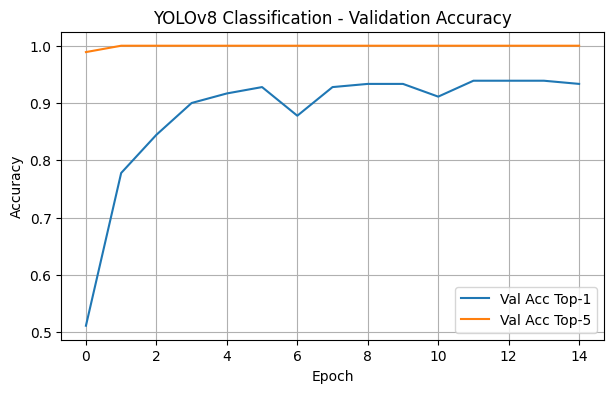

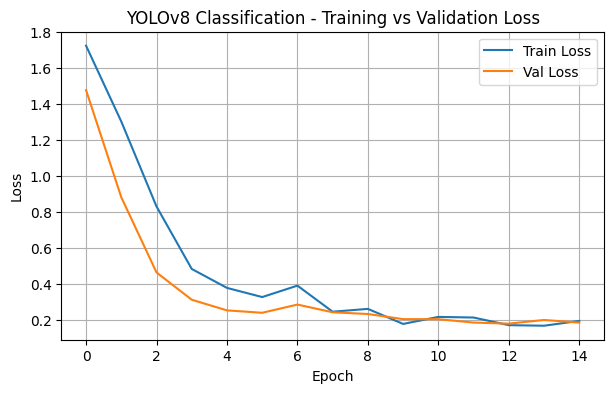

In [65]:
# 7) Plot training curves (Accuracy + Loss) from Ultralytics results.csv
# =========================
import pandas as pd
import matplotlib.pyplot as plt
import os

RUN_DIR = "/kaggle/working/runs/eggplant_yolo_cls"   # same as project/name in train()
CSV_PATH = os.path.join(RUN_DIR, "results.csv")

if not os.path.exists(CSV_PATH):
    raise FileNotFoundError(f"results.csv not found at: {CSV_PATH}\nCheck RUN_DIR or your project/name.")

df = pd.read_csv(CSV_PATH)
df.columns = [c.strip() for c in df.columns]  # clean column names

print("✅ Available columns:", df.columns.tolist())

# ---- Plot Accuracy (Top-1 and Top-5 if available) ----
plt.figure(figsize=(7,4))
if "metrics/accuracy_top1" in df.columns:
    plt.plot(df["metrics/accuracy_top1"], label="Val Acc Top-1")
if "metrics/accuracy_top5" in df.columns:
    plt.plot(df["metrics/accuracy_top5"], label="Val Acc Top-5")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("YOLOv8 Classification - Validation Accuracy")
plt.grid(True)
plt.legend()
plt.show()

# ---- Plot Loss (train + val) ----
plt.figure(figsize=(7,4))
if "train/loss" in df.columns:
    plt.plot(df["train/loss"], label="Train Loss")
if "val/loss" in df.columns:
    plt.plot(df["val/loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv8 Classification - Training vs Validation Loss")
plt.grid(True)
plt.legend()
plt.show()

In [66]:
import os
import numpy as np
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix

VAL_DIR = Path(OUT_ROOT) / "val"

image_paths = []
true_labels = []
class_names = sorted(os.listdir(VAL_DIR))

for idx, cls in enumerate(class_names):
    cls_folder = VAL_DIR / cls
    for img in cls_folder.glob("*.*"):
        image_paths.append(str(img))
        true_labels.append(idx)

print("Total validation images:", len(image_paths))

Total validation images: 180


In [67]:
pred_labels = []

for img_path in image_paths:
    result = model.predict(img_path, imgsz=160, verbose=False)[0]
    pred_labels.append(int(result.probs.top1))

report = classification_report(
    true_labels,
    pred_labels,
    target_names=class_names
)

print("Classification Report:\n")
print(report)


Classification Report:

                                  precision    recall  f1-score   support

Eggplant Cercospora Leaf Disease       0.88      0.97      0.92        30
   Eggplant Healthy Leaf Disease       0.90      0.90      0.90        30
    Eggplant Insect Pest Disease       0.90      0.90      0.90        30
      Eggplant Leaf Spot Disease       0.96      0.77      0.85        30
 Eggplant Powdery mildew Disease       0.97      0.93      0.95        30
           Eggplant Wilt Disease       0.88      1.00      0.94        30

                        accuracy                           0.91       180
                       macro avg       0.91      0.91      0.91       180
                    weighted avg       0.91      0.91      0.91       180



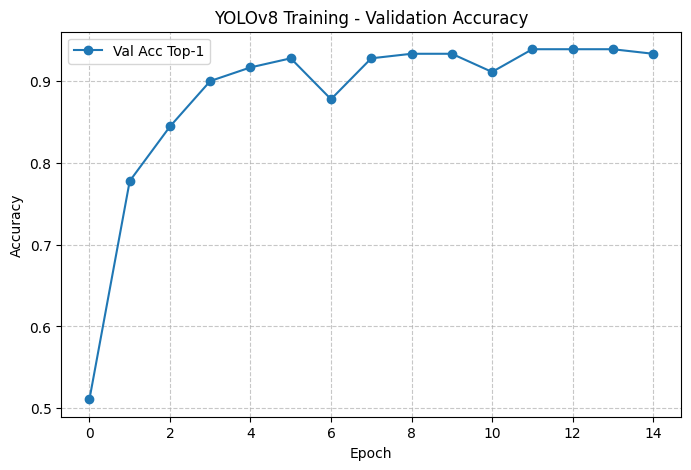

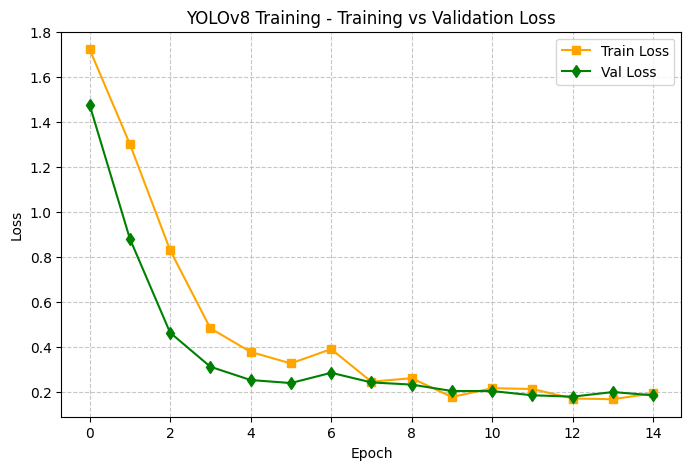

✅ Plots generated and saved as 'accuracy_plot.png' and 'loss_plot.png'


In [68]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1) Locate the results file
# Adjust this path if your training run created a folder like 'eggplant_yolo_cls2'
RESULTS_PATH = "/kaggle/working/runs/eggplant_yolo_cls/results.csv"

if os.path.exists(RESULTS_PATH):
    # Load the data
    df = pd.read_csv(RESULTS_PATH)
    
    # Strip any extra spaces from column names (common in YOLO results)
    df.columns = [c.strip() for c in df.columns]

    # ---- Plot Accuracy ----
    plt.figure(figsize=(8, 5))
    if "metrics/accuracy_top1" in df.columns:
        plt.plot(df["metrics/accuracy_top1"], marker='o', label="Val Acc Top-1")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("YOLOv8 Training - Validation Accuracy")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    # Save for your report
    plt.savefig("accuracy_plot.png")
    plt.show()

    # ---- Plot Loss ----
    plt.figure(figsize=(8, 5))
    if "train/loss" in df.columns:
        plt.plot(df["train/loss"], marker='s', label="Train Loss", color='orange')
    if "val/loss" in df.columns:
        plt.plot(df["val/loss"], marker='d', label="Val Loss", color='green')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("YOLOv8 Training - Training vs Validation Loss")
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    # Save for your report
    plt.savefig("loss_plot.png")
    plt.show()
    
    print("✅ Plots generated and saved as 'accuracy_plot.png' and 'loss_plot.png'")
else:
    print(f"❌ Results file not found at: {RESULTS_PATH}")
    print("Ensure your training finished successfully or check the folder name in 'working/runs/'")

In [69]:
cm = confusion_matrix(true_labels, pred_labels)
print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[29  0  0  0  0  1]
 [ 0 27  2  1  0  0]
 [ 1  0 27  0  0  2]
 [ 1  3  1 23  1  1]
 [ 2  0  0  0 28  0]
 [ 0  0  0  0  0 30]]
